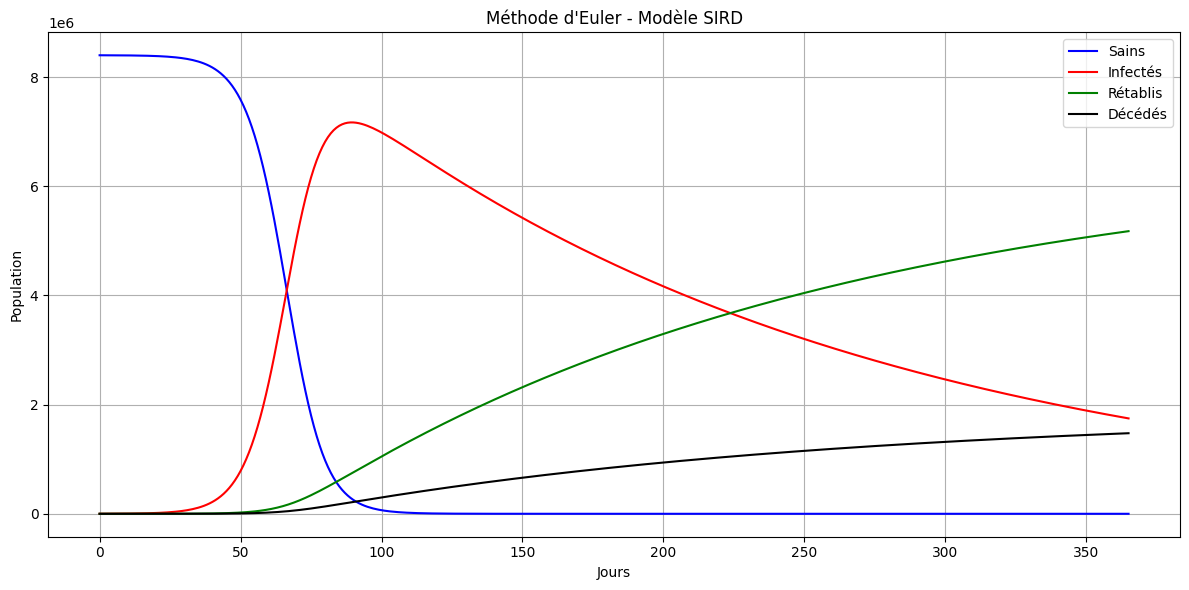

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres estimés
a = 0.14993974126532622
b = 0.004086788414607084
r = 0.0011650485436893205

# Paramètres initiaux
N = 8_250_000
days = 365
h = 1

I0 = 1000
R0 = 0
D0 = 0
S0 = N - I0 - R0 - D0

t = np.arange(0, days + 1)
S, I, R, D = np.zeros(len(t)), np.zeros(len(t)), np.zeros(len(t)), np.zeros(len(t))
S[0], I[0], R[0], D[0] = S0, I0, R0, D0

# Simulation avec Euler
for n in range(len(t) - 1):
    dS = -a * S[n] * I[n] / N
    dI = a * S[n] * I[n] / N - b * I[n] - r * I[n]
    dR = b * I[n]
    dD = r * I[n]

    S[n+1] = S[n] + h * dS
    I[n+1] = I[n] + h * dI
    R[n+1] = R[n] + h * dR
    D[n+1] = D[n] + h * dD

# Affichage du graphe
plt.figure(figsize=(12, 6))
plt.plot(t, S, label='Sains', color='blue')
plt.plot(t, I, label='Infectés', color='red')
plt.plot(t, R, label='Rétablis', color='green')
plt.plot(t, D, label='Décédés', color='black')
plt.title("Méthode d'Euler - Modèle SIRD")
plt.xlabel("Jours")
plt.ylabel("Population")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


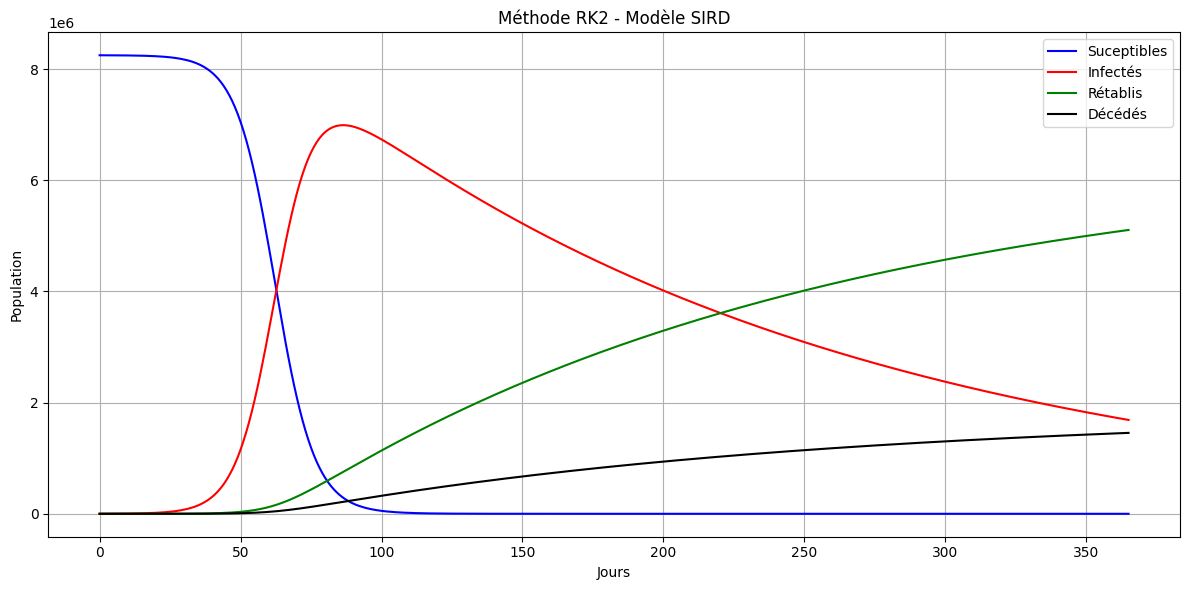

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres estimés
a = 0.14993974126532622
b = 0.004086788414607084
r = 0.0011650485436893205

# Paramètres initiaux
N = 8_250_000
days = 365
h = 1

I0 = 1000
R0 = 0
D0 = 0
S0 = N - I0 - R0 - D0

t = np.arange(0, days + 1)
S, I, R, D = np.zeros(len(t)), np.zeros(len(t)), np.zeros(len(t)), np.zeros(len(t))
S[0], I[0], R[0], D[0] = S0, I0, R0, D0

# Simulation avec RK2
for n in range(len(t) - 1):
    Sn, In, Rn, Dn = S[n], I[n], R[n], D[n]

    dS1 = -a * Sn * In / N
    dI1 = a * Sn * In / N - b * In - r * In
    dR1 = b * In
    dD1 = r * In

    S_half = Sn + 0.5 * h * dS1
    I_half = In + 0.5 * h * dI1
    R_half = Rn + 0.5 * h * dR1
    D_half = Dn + 0.5 * h * dD1

    dS2 = -a * S_half * I_half / N
    dI2 = a * S_half * I_half / N - b * I_half - r * I_half
    dR2 = b * I_half
    dD2 = r * I_half

    S[n+1] = Sn + h * dS2
    I[n+1] = In + h * dI2
    R[n+1] = Rn + h * dR2
    D[n+1] = Dn + h * dD2

# Affichage du graphe
plt.figure(figsize=(12, 6))
plt.plot(t, S, label='Suceptibles', color='blue')
plt.plot(t, I, label='Infectés', color='red')
plt.plot(t, R, label='Rétablis', color='green')
plt.plot(t, D, label='Décédés', color='black')
plt.title("Méthode RK2 - Modèle SIRD")
plt.xlabel("Jours")
plt.ylabel("Population")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

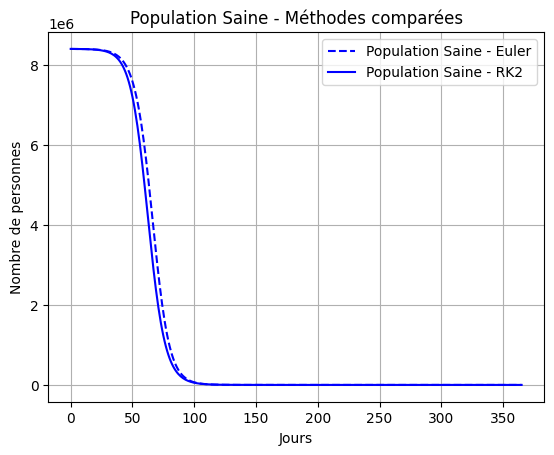

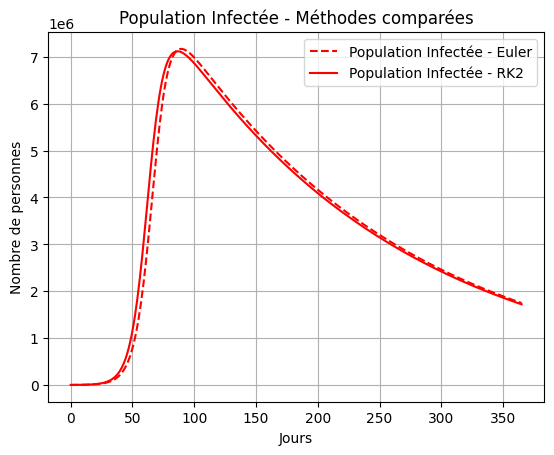

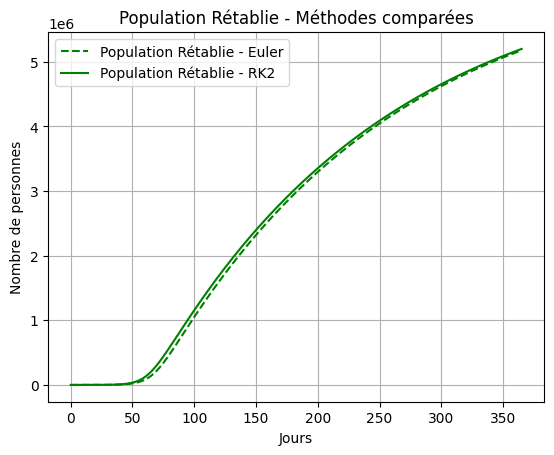

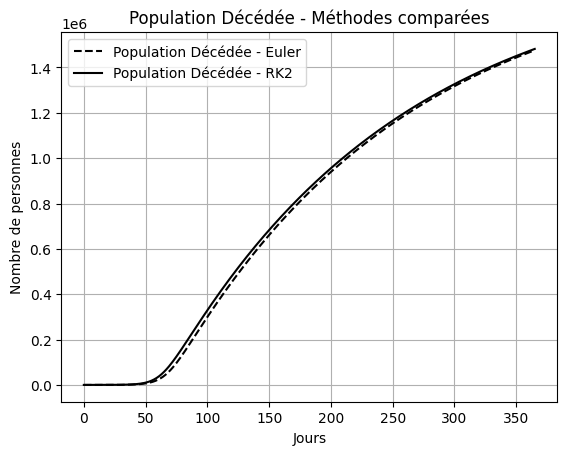

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres estimés
a = 0.14993974126532622
b = 0.004086788414607084
r = 0.0011650485436893205

# Paramètres généraux
N = 8_400_000
days = 365
h = 1

# Conditions initiales
I0 = 1000
R0 = 0
D0 = 0
S0 = N - I0 - R0 - D0


t = np.arange(0, days + 1)

#Méthode d'Euler
def sird_euler():
    S, I, R, D = np.zeros(len(t)), np.zeros(len(t)), np.zeros(len(t)), np.zeros(len(t))
    S[0], I[0], R[0], D[0] = S0, I0, R0, D0

    for n in range(len(t) - 1):
        dS = -a * S[n] * I[n] / N
        dI = a * S[n] * I[n] / N - b * I[n] - r * I[n]
        dR = b * I[n]
        dD = r * I[n]

        S[n+1] = S[n] + h * dS
        I[n+1] = I[n] + h * dI
        R[n+1] = R[n] + h * dR
        D[n+1] = D[n] + h * dD
    return S, I, R, D

#Méthode de Runge-Kutta
def sird_rk2():
    S, I, R, D = np.zeros(len(t)), np.zeros(len(t)), np.zeros(len(t)), np.zeros(len(t))
    S[0], I[0], R[0], D[0] = S0, I0, R0, D0

    for n in range(len(t) - 1):
        Sn, In, Rn, Dn = S[n], I[n], R[n], D[n]

        dS1 = -a * Sn * In / N
        dI1 = a * Sn * In / N - b * In - r * In
        dR1 = b * In
        dD1 = r * In

        S_half = Sn + 0.5 * h * dS1
        I_half = In + 0.5 * h * dI1
        R_half = Rn + 0.5 * h * dR1
        D_half = Dn + 0.5 * h * dD1

        dS2 = -a * S_half * I_half / N
        dI2 = a * S_half * I_half / N - b * I_half - r * I_half
        dR2 = b * I_half
        dD2 = r * I_half

        S[n+1] = Sn + h * dS2
        I[n+1] = In + h * dI2
        R[n+1] = Rn + h * dR2
        D[n+1] = Dn + h * dD2
    return S, I, R, D

S_e, I_e, R_e, D_e = sird_euler()
S_rk, I_rk, R_rk, D_rk = sird_rk2()

def plot_comparison(data_euler, data_rk, label, color):
    plt.figure()
    plt.plot(t, data_euler, '--', label=f"{label} - Euler", color=color)
    plt.plot(t, data_rk, '-', label=f"{label} - RK2", color=color)
    plt.title(f"{label} - Méthodes comparées")
    plt.xlabel("Jours")
    plt.ylabel("Nombre de personnes")
    plt.legend()
    plt.grid(True)
    plt.show()

#Graphes
plot_comparison(S_e, S_rk, "Population Saine", "blue")
plot_comparison(I_e, I_rk, "Population Infectée", "red")
plot_comparison(R_e, R_rk, "Population Rétablie", "green")
plot_comparison(D_e, D_rk, "Population Décédée", "black")